# 2025/2026: Ma513 — Session 3: ML for  Malware Threat Detection

**Duration:** 2h  

**Tools:** Python, pandas, numpy, matplotlib, scikit-learn.


> This lab follows the session 3 outline (Supervised and Unsupervised ML for Malware Threat Detection). The `scikit-learn` documentation is complete and should be consulted whenever necessary. In particular herein you can consult:

https://scikit-learn.org/stable/modules/tree.html

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html

https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html


## A. Malware Artifacts

### 1. Decision tree and Random Forest

In this exercise, you will extract malware artifacts in the given dataset `MalwareArtifacts.csv` and you will use the **AddressOfEntryPoint** and **DllCharacteristics** fields as potentially distinctive features for detecting the suspect.

1. Start by importing the relevant libraries and the given dataset.

In [43]:
# If you are missing a package, install it in your environment, e.g.:
# !pip install package ...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,confusion_matrix


2. Extract artifacts samples fields **AddressOfEntryPoint** as samples and **DllCharacteristics** as targets.

In [24]:
# TODO: your code
data = pd.read_csv('MalwareArtifacts.csv')
data.head()
samples = data[['AddressOfEntryPoint','DllCharacteristics']]
targets = data['legitimate']

3. Using the `scikit-learn` package, split samples and targets into training samples, testing_samples, training_targets and testing_targets.

In [25]:
# TODO: your code
samples_train, samples_test, targets_train, targets_test = train_test_split(samples, targets, test_size=0.2, random_state=42)

4. Fit a **classification decision tree** on your training dataset.

In [27]:
# TODO: your code
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(samples_train, targets_train)

DecisionTreeClassifier(random_state=42)

5. Use this model to make a prediction now then compute its accuracy score. What do you conclude?

In [31]:
# TODO: your code
dtc.predict(samples_test.values)
accuracy_score(targets_test, dtc.predict(samples_test.values))*100

# This can be better but its already convenient

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


96.45312670522755

6. Answer the previous two questions again using a **random forest model** then compare the both models accuracy. What do you remark?

In [33]:
# TODO: your code
rfc = RandomForestClassifier(random_state=42)
rfc.fit(samples_train.values, targets_train)
accuracy_score(targets_test, rfc.predict(samples_test.values))*100

# After comparaison, the Random Forest Classifier is a bit better (0.09 % better) but the differences in terms of accurency is close so we can say that both model is good. This is due to the fact that the dataset don't have a lot of data, so the random forest didn't shine of all his capability (there is only 8 features)


96.54770999308815

### 2. K-means Clustering

You will apply now the K-Means clustering algorithm to the dataset of artifacts. The number of clusters that we will assign to the k parameter in the algorithm initialization
phase will be 2, while the features that we will select as distinctive criteria of the possible malware correspond to the **MajorLinkerVersion**, **MajorImageVersion**,
**MajorOperatingSystemVersion**, and **DllCharacteristics** fields:

1. Define the samples and the target.

In [45]:
# TODO: your code
samples = data[['MajorLinkerVersion', 'MajorImageVersion', 'MajorOperatingSystemVersion', 'DllCharacteristics']]
targets = data['legitimate']

2.Once  the fields of interest from the dataset are selected, you can proceed to instantiate the K-Means where the number of clusters is equal to 2 (n_clusters = 2), and the maximum number of iterations that the algorithm can execute is equal to  300 (max_iter = 300).

In [40]:
# TODO: your code
kmean = KMeans(n_clusters=2, max_iter=300)
samples_train, samples_test, targets_train, targets_test = train_test_split(samples, targets, test_size=0.2, random_state=42)

3. Train the K-Means model on the samples. Then evaluate the obtained results. For this purpose you can use the **silhouette coefficient** and the **confusion matrix**. Conclude

In [44]:
# TODO: your code
kmean.fit(samples_train)
silhouette_score(samples_train, kmean.labels_) #95.75%
confusion_matrix(targets_train, kmean.labels_)

array([[66843, 10497],
       [ 7045, 25570]])

## 2. Knowledge Discovery Database

Software to detect network intrusions protects a computer network from unauthorized users, including perhaps insiders.
The intrusion detector learning task is to build a predictive model capable of distinguishing between ''bad'' connections, called intrusions or attacks, and ''good'' normal connections.

In this exercise,you will consider the KDD (Knowledge Discovery Database) that contains a standard set of data to be audited, which includes a wide variety of intrusions simulated in a military network environment.

1. Start by importing the relevant packages for the exercise.

In [46]:
# TODO: your code

2. The following code loads the KDD data:

In [47]:
from sklearn.datasets import fetch_kddcup99
dataset = fetch_kddcup99(subset=None, shuffle=True, percent10=True)

From this dataset, build $𝑋$ as the data and $𝑌$ as the target.

In [48]:
# TODO: your code
x = dataset.data
y = dataset.target

3. The KDD has several features that we could print using this sentence:

In [49]:
feature_cols = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serrer_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']

Using `pandas.Dataframe`, structure the data so that it takes the previous feature_cols as columns, and put the target in the right form using `pandas.Series`.

In [50]:
# TODO: your code
pd.DataFrame(x, columns=feature_cols)
pd.Series(y)

,0
0,b'normal.'
1,b'smurf.'
2,b'smurf.'
3,b'smurf.'
4,b'neptune.'
...,...
494016,b'normal.'
494017,b'normal.'
494018,b'smurf.'
494019,b'smurf.'


4. Print the data and visualize it.

In [51]:
# TODO: your code
print(x)
print(y)

[[0 b'tcp' b'smtp' ... 0.0 0.0 0.0]
 [0 b'icmp' b'ecr_i' ... 0.0 0.0 0.0]
 [0 b'icmp' b'ecr_i' ... 0.0 0.0 0.0]
 ...
 [0 b'icmp' b'ecr_i' ... 0.0 0.0 0.0]
 [0 b'icmp' b'ecr_i' ... 0.0 0.0 0.0]
 [0 b'tcp' b'private' ... 1.0 0.0 0.0]]
[b'normal.' b'smurf.' b'smurf.' ... b'smurf.' b'smurf.' b'neptune.']


5. In the following, for efficient processing, convert the columns into floats. Then convert the categorical into dummy or indicator variables.

In [54]:
# Identify categorical columns
categorical_cols = ['protocol_type', 'service', 'flag']

# Convert categorical columns to dummy variables
x_processed = pd.get_dummies(pd.DataFrame(x, columns=feature_cols), columns=categorical_cols)

# Convert all columns to float
x_data = x_processed.astype(float)

# Convert target to numerical (assuming 'normal.' is benign and others are attacks)
# You might need to adjust this based on the actual labels in your dataset
y_data = (y != b'normal.').astype(int)

print("Processed X (first 5 rows):")
print(x_data.head())
print("\nProcessed Y (first 5 rows):")
print(y_data[:5])

Processed X (first 5 rows):
   duration  src_bytes  dst_bytes  land  wrong_fragment  urgent  hot  \
0       0.0      861.0      328.0   0.0             0.0     0.0  0.0   
1       0.0      520.0        0.0   0.0             0.0     0.0  0.0   
2       0.0     1032.0        0.0   0.0             0.0     0.0  0.0   
3       0.0     1032.0        0.0   0.0             0.0     0.0  0.0   
4       0.0        0.0        0.0   0.0             0.0     0.0  0.0   

   num_failed_logins  logged_in  num_compromised  ...  flag_b'REJ'  \
0                0.0        1.0              0.0  ...          0.0   
1                0.0        0.0              0.0  ...          0.0   
2                0.0        0.0              0.0  ...          0.0   
3                0.0        0.0              0.0  ...          0.0   
4                0.0        0.0              0.0  ...          0.0   

   flag_b'RSTO'  flag_b'RSTOS0'  flag_b'RSTR'  flag_b'S0'  flag_b'S1'  \
0           0.0             0.0           0.0

6. Visualize the frequency of each unique value in the target variable.

In [56]:
# TODO: your code
unique_values, frequencies = np.unique(y_data, return_counts=True)
print(dict(zip(unique_values, frequencies)))

{np.int64(0): np.int64(97278), np.int64(1): np.int64(396743)}


7. Fit a **classification tree** with `max_depth=7` on all data. Then create the corresponding Graphviz file to visualize the results of the decision tree with a graph.

In [65]:
# TODO: your code
clt = DecisionTreeClassifier(max_depth=7)
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42)
clt.fit(x_train, y_train)


DecisionTreeClassifier(max_depth=7)

In [83]:
from sklearn.tree import export_graphviz

# Generate Graphviz file
export_graphviz(clt, out_file='tree.dot', feature_names=x_data.columns, class_names=['normal', 'attack'], filled=True, rounded=True, special_characters=True)


A file named `tree.dot` has been generated in your Colab environment. You can download this file and use a Graphviz viewer (like [Graphviz Online](https://dreampuf.github.io/GraphvizOnline/) or the desktop application) to visualize the decision tree.

8. The following sentence gives us the feature importance:

In [66]:
pd.DataFrame({'feature':x_data.columns,'importance':clt.feature_importances_}).sort_values('importance', ascending=False).head(10)

,feature,importance
19,count,0.884743
1,src_bytes,0.027311
2,dst_bytes,0.025718
63,service_b'http',0.024438
6,hot,0.023943
4,wrong_fragment,0.003221
60,service_b'ftp_data',0.002987
32,dst_host_same_src_port_rate,0.002200
33,dst_host_srv_diff_host_rate,0.002158
35,dst_host_srv_serror_rate,0.000760


Print the output. What do you think about it?

In [67]:
# TODO: your code
print(clt.predict(x_train))

[1 1 1 ... 1 1 1]


9. How about a **random forest** model now?

In [69]:
# TODO: your code
rfc = RandomForestClassifier()
rfc.fit(x_train, y_train)
print(rfc.predict(x_train))

[1 1 1 ... 1 1 1]


10. Evaluate both previous estimators’ performances using cross-validation from `scikit-learn`.

https://scikit-learn.org/stable/modules/cross_validation.html. Conclude.

In [70]:
# TODO: your code
from sklearn.model_selection import cross_val_score

cross_val_score(clt, x_data, y_data, cv=5)
cross_val_score(rfc, x_data, y_data, cv=5)

array([0.99987855, 0.9998077 , 0.99979758, 0.99987855, 0.9998077 ])

The **Isolation Forest** ‘isolates’ observations by randomly selecting a feature and then randomly selecting a split value between the maximum and minimum values of the selected feature.

In this example we will want to use binary data where 1 will represent a "not-normal" attack:

In [71]:
y_binary = y != 'normal.'

11. Divide the data into train and test sets.

In [72]:
# TODO: your code
x_train, x_test, y_train, y_test = train_test_split(x_data, y_binary, test_size=0.2, random_state=42)

12. Apply the **IsolationForest** model to fit the data. Then make a prediction.

In [74]:
# TODO: your code
from sklearn.ensemble import IsolationForest

isf = IsolationForest()
isf.fit(x_train, y_train)

IsolationForest()

13. Evaluate the performance of the model using the `accuracy_score`. Conclude.

In [77]:
# TODO: your code
accuracy_score(y_test, isf.predict(x_test))*100

87.13223015029604

## C. Synthetic dataset

You will apply now IsolationForest model to detect malware-like anomalies using synthetic PE-file features.

1. Run the following cell to generate the dataset.

In [103]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, precision_score, recall_score
)
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_STATE = 2025  # TODO: you can change this for experiments
np.random.seed(RANDOM_STATE)

# Synthetic PE-like feature generator
def generate_synthetic_pe_data(n_good=2000, n_malware=300, random_state=2025):
    """
    Generate a labeled dataset with benign (0) and malware (1) samples.
    Features emulate PE-file characteristics: file size, entropy, section count, imports,
    suspicious API calls, and strings count.
    """
    rng = np.random.RandomState(random_state)

    def good_samples(n):
        return pd.DataFrame({
            'file_size_kb': rng.normal(loc=300, scale=120, size=n).clip(10),
            'entropy': rng.normal(loc=5.0, scale=0.5, size=n).clip(0, 8),
            'section_count': rng.poisson(lam=5, size=n).clip(1),
            'import_count': rng.poisson(lam=30, size=n),
            'suspicious_api_calls': rng.poisson(lam=1, size=n),
            'strings_count': rng.normal(loc=800, scale=300, size=n).clip(0)
        })

    def malware_samples(n):
        return pd.DataFrame({
            'file_size_kb': np.concatenate([
                rng.normal(loc=50, scale=30, size=int(n*0.6)),
                rng.normal(loc=2000, scale=800, size=int(n*0.4))
            ])[:n].clip(5),
            'entropy': rng.normal(loc=6.5, scale=0.7, size=n).clip(0, 8),
            'section_count': rng.poisson(lam=8, size=n).clip(1),
            'import_count': rng.poisson(lam=120, size=n),
            'suspicious_api_calls': rng.poisson(lam=8, size=n),
            'strings_count': rng.normal(loc=200, scale=150, size=n).clip(0)
        })

    df_good = good_samples(n_good); df_good['label'] = 0
    df_bad  = malware_samples(n_malware); df_bad['label'] = 1
    df = pd.concat([df_good, df_bad], ignore_index=True)
    return df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

# Generate data
df = generate_synthetic_pe_data(n_good=2000, n_malware=300, random_state=RANDOM_STATE)

# Quick EDA
print("Dataset shape:", df.shape)
print("Class balance (0=benign, 1=malware):")
print(df['label'].value_counts(normalize=True).rename('ratio'))

# Feature/label split
X = df.drop(columns=['label'])
y = df['label']

Dataset shape: (2300, 7)
Class balance (0=benign, 1=malware):
label
0    0.869565
1    0.130435
Name: ratio, dtype: float64


2. Split your data and apply the **IsolationForest** model to fit the data. Then make a prediction on the test set.

In [106]:
# TODO: Your code

# Train/test split

    # Your code
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# IsolationForest! Experiment with these hyperparameters
    # n_estimators = 100, 200, 400
    # contamination = 0.01, 0.03, 0.05, 0.10
    # max_samples = 'auto' or an int like 256/512

    # Your code
isf = IsolationForest(n_estimators=100, contamination=0.01, max_samples=512)
isf.fit(x_train, y_train)

# Predict on test set

    # Your code
isf.predict(x_test)

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

3. Evaluate the precision and the recall of your model, the plot the **ROC** curve and conclude. For this purpose, consult https://scikit-learn.org/1.1/auto_examples/model_selection/plot_roc.html .

Precision: 88.9130
ROC AUC: 0.0051


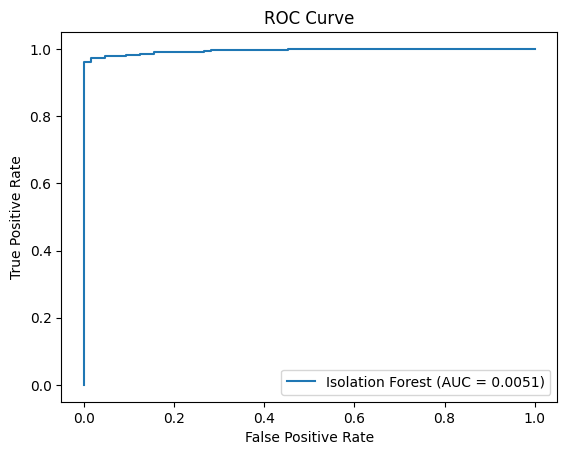

In [121]:
#TODO: Your code
# Evaluation
y_pred = isf.predict(x_test)
# Isolation Forest predicts 1 for inliers and -1 for outliers.
# Convert to 0 for benign (inliers) and 1 for malware (outliers) for evaluation

y_pred_binary = np.where(y_pred == -1, 1, 0)
precision = accuracy_score(y_test, y_pred_binary)*100
roc_auc = roc_auc_score(y_test, isf.decision_function(x_test))

print(f"Precision: {precision:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")


# ROC curve plot
fpr, tpr, thresholds = roc_curve(y_test, isf.decision_function(x_test))
plt.plot(tpr, fpr, label=f'Isolation Forest (AUC = {roc_auc:.4f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

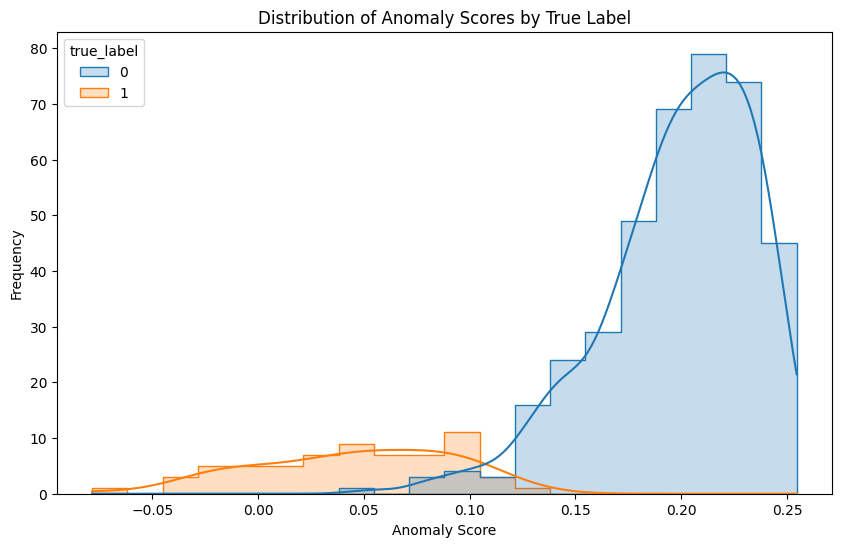

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get anomaly scores for the test set
anomaly_scores = isf.decision_function(x_test)

# Create a DataFrame for easier plotting
results_df = pd.DataFrame({'anomaly_score': anomaly_scores, 'true_label': y_test})

# Plot distributions
plt.figure(figsize=(10, 6))
sns.histplot(data=results_df, x='anomaly_score', hue='true_label', kde=True, element='step')
plt.title('Distribution of Anomaly Scores by True Label')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.show()

4. Why is **IsolationForest** appropriate for malware anomaly detection? How does it differ from clustering?

In [122]:
#Its effecient with multiple feature, and because malware have multiple features, the IsolationForest is the best
#The Isolation forest help locate anomaly (malware code into healthy code) and the clustering regroup all anomaly together (the first one is faster)